In [18]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
print("ready!")


ready!


In [19]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import os

# ─────────────────────────────────────────
# CHOOSE YOUR DATA SOURCE
# ─────────────────────────────────────────

use_own_data = False  # Change to True if you have your own CSV

if use_own_data:
    # Place your CSV in the same folder and write the filename below
    df = pd.read_csv("your_file.csv")
    print("Loaded your own dataset!")
else:
    print("Using built-in sample dataset...")

Using built-in sample dataset...


In [20]:
if not use_own_data:
    data = {
        "sale_id": range(1, 51),
        "month": ["January","January","January","January","January",
                  "February","February","February","February","February",
                  "March","March","March","March","March",
                  "April","April","April","April","April",
                  "May","May","May","May","May",
                  "June","June","June","June","June",
                  "July","July","July","July","July",
                  "August","August","August","August","August",
                  "September","September","September","September","September",
                  "October","October","October","October","October"],
        "model": ["C-Class","E-Class","GLC","A-Class","S-Class",
                   "GLC","C-Class","E-Class","A-Class","GLE",
                   "S-Class","C-Class","GLC","E-Class","A-Class",
                   "GLE","S-Class","C-Class","GLC","E-Class",
                   "A-Class","GLC","C-Class","S-Class","E-Class",
                   "GLE","A-Class","C-Class","GLC","E-Class",
                   "S-Class","GLC","C-Class","A-Class","E-Class",
                   "GLE","C-Class","GLC","E-Class","S-Class",
                   "A-Class","C-Class","GLC","E-Class","GLE",
                   "S-Class","C-Class","A-Class","GLC","E-Class"],
        "region": ["Stuttgart","Munich","Berlin","Hamburg","Stuttgart",
                    "Munich","Berlin","Stuttgart","Hamburg","Munich",
                    "Berlin","Stuttgart","Hamburg","Munich","Berlin",
                    "Stuttgart","Munich","Hamburg","Berlin","Stuttgart",
                    "Munich","Berlin","Stuttgart","Hamburg","Munich",
                    "Berlin","Stuttgart","Munich","Hamburg","Berlin",
                    "Stuttgart","Munich","Berlin","Hamburg","Stuttgart",
                    "Munich","Berlin","Stuttgart","Hamburg","Munich",
                    "Berlin","Stuttgart","Hamburg","Munich","Berlin",
                    "Stuttgart","Munich","Berlin","Hamburg","Stuttgart"],
        "sale_price": [42000,58000,51000,31000,95000,
                       52000,43000,59000,32000,72000,
                       96000,44000,53000,61000,33000,
                       74000,97000,45000,54000,62000,
                       34000,55000,46000,98000,63000,
                       75000,35000,47000,56000,64000,
                       99000,57000,48000,36000,65000,
                       76000,49000,58000,66000,100000,
                       37000,50000,59000,67000,77000,
                       101000,51000,38000,60000,68000],
        "financing": ["Yes","No","Yes","Yes","No",
                      "Yes","No","Yes","No","Yes",
                      "No","Yes","Yes","No","Yes",
                      "Yes","No","Yes","Yes","No",
                      "Yes","Yes","No","No","Yes",
                      "Yes","Yes","No","Yes","Yes",
                      "No","Yes","Yes","Yes","No",
                      "Yes","No","Yes","Yes","No",
                      "Yes","Yes","Yes","No","Yes",
                      "No","Yes","Yes","Yes","No"]
    }
    df = pd.DataFrame(data)

# Load into SQL database
conn = sqlite3.connect("mercedes_sales.db")
df.to_sql("sales", conn, if_exists="replace", index=False)

print("Database created!")
print(df.head())

Database created!
   sale_id    month    model     region  sale_price financing
0        1  January  C-Class  Stuttgart       42000       Yes
1        2  January  E-Class     Munich       58000        No
2        3  January      GLC     Berlin       51000       Yes
3        4  January  A-Class    Hamburg       31000       Yes
4        5  January  S-Class  Stuttgart       95000        No


In [21]:
# KPI 1: Total revenue
total_revenue = pd.read_sql("SELECT SUM(sale_price) as Total_Revenue FROM sales", conn)
print("Total Revenue:")
print(total_revenue)

# KPI 2: Revenue by model
revenue_by_model = pd.read_sql("""
    SELECT model, 
           COUNT(*) as Units_Sold,
           SUM(sale_price) as Total_Revenue,
           AVG(sale_price) as Avg_Price
    FROM sales 
    GROUP BY model 
    ORDER BY Total_Revenue DESC
""", conn)
print("\nRevenue by Model:")
print(revenue_by_model)

# KPI 3: Revenue by region
revenue_by_region = pd.read_sql("""
    SELECT region,
           COUNT(*) as Units_Sold,
           SUM(sale_price) as Total_Revenue
    FROM sales
    GROUP BY region
    ORDER BY Total_Revenue DESC
""", conn)
print("\nRevenue by Region:")
print(revenue_by_region)

# KPI 4: Financing rate
financing_rate = pd.read_sql("""
    SELECT financing,
           COUNT(*) as Count,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM sales), 1) as Percentage
    FROM sales
    GROUP BY financing
""", conn)
print("\nFinancing Rate:")
print(financing_rate)

# KPI 5: Monthly revenue trend
monthly_trend = pd.read_sql("""
    SELECT month, SUM(sale_price) as Monthly_Revenue
    FROM sales
    GROUP BY month
""", conn)
print("\nMonthly Trend:")
print(monthly_trend)

Total Revenue:
   Total_Revenue
0        2989000

Revenue by Model:
     model  Units_Sold  Total_Revenue  Avg_Price
0  S-Class           7         686000    98000.0
1  E-Class          10         633000    63300.0
2      GLC          10         555000    55500.0
3  C-Class          10         465000    46500.0
4      GLE           5         374000    74800.0
5  A-Class           8         276000    34500.0

Revenue by Region:
      region  Units_Sold  Total_Revenue
0  Stuttgart          14         898000
1     Munich          13         835000
2     Berlin          13         720000
3    Hamburg          10         536000

Financing Rate:
  financing  Count  Percentage
0        No     18        36.0
1       Yes     32        64.0

Monthly Trend:
       month  Monthly_Revenue
0      April           332000
1     August           349000
2   February           258000
3    January           277000
4       July           305000
5       June           277000
6      March           287000
7  

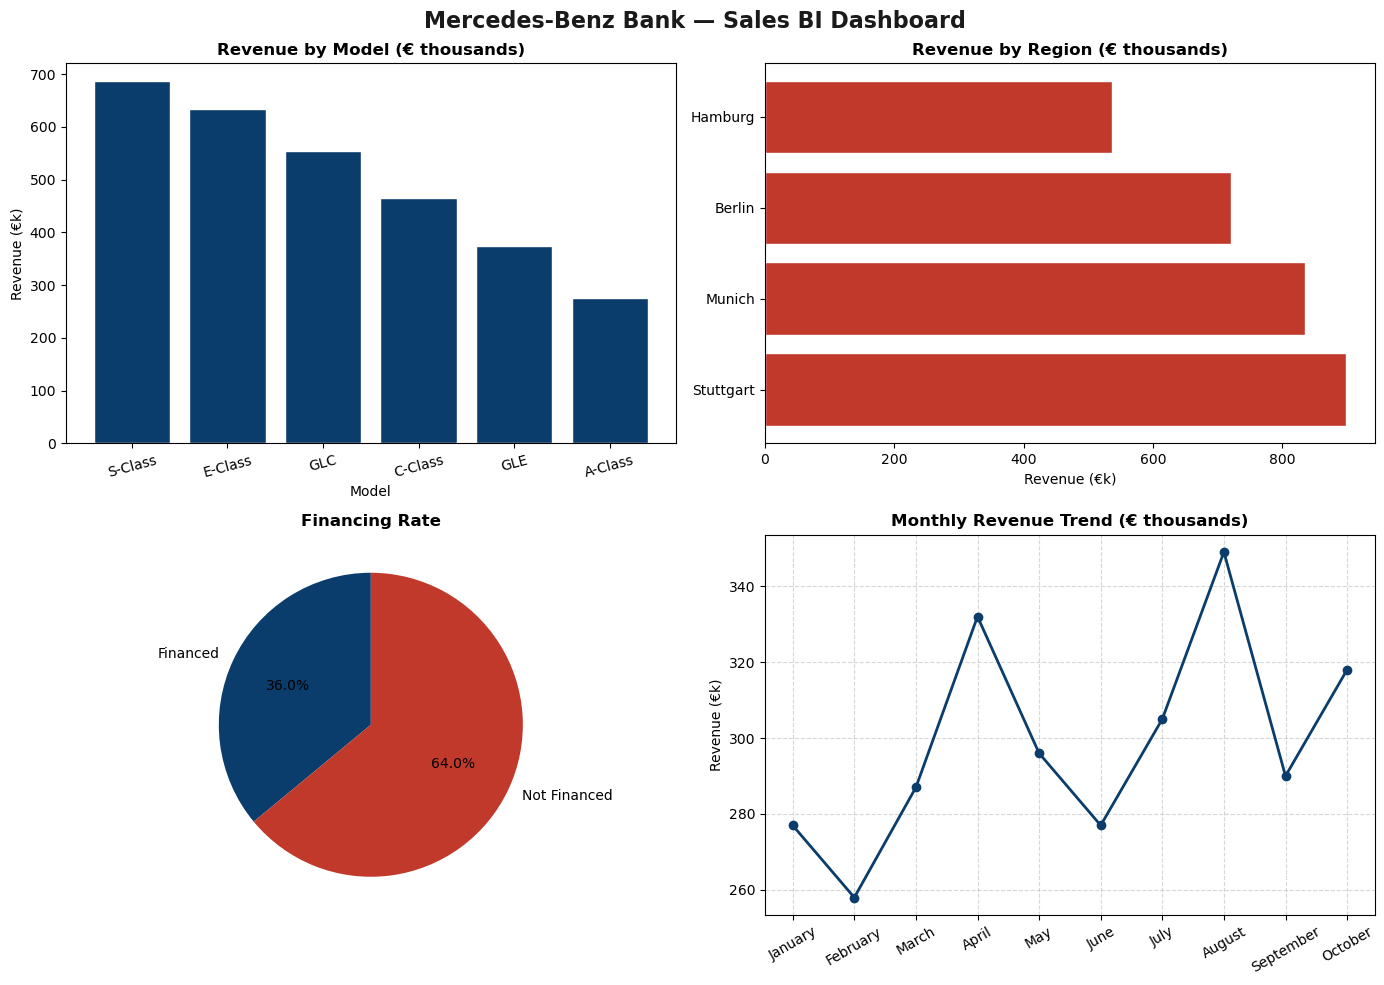

Dashboard saved!


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Mercedes-Benz Bank — Sales BI Dashboard", 
             fontsize=16, fontweight="bold", color="#1a1a1a")

# Chart 1 — Revenue by model
axes[0,0].bar(revenue_by_model["model"], 
              revenue_by_model["Total_Revenue"] / 1000,
              color="#0a3d6b", edgecolor="white")
axes[0,0].set_title("Revenue by Model (€ thousands)", fontweight="bold")
axes[0,0].set_xlabel("Model")
axes[0,0].set_ylabel("Revenue (€k)")
axes[0,0].tick_params(axis="x", rotation=15)

# Chart 2 — Revenue by region
axes[0,1].barh(revenue_by_region["region"],
               revenue_by_region["Total_Revenue"] / 1000,
               color="#c0392b", edgecolor="white")
axes[0,1].set_title("Revenue by Region (€ thousands)", fontweight="bold")
axes[0,1].set_xlabel("Revenue (€k)")

# Chart 3 — Financing pie chart
axes[1,0].pie(financing_rate["Count"],
              labels=["Financed", "Not Financed"],
              autopct="%1.1f%%",
              colors=["#0a3d6b", "#c0392b"],
              startangle=90)
axes[1,0].set_title("Financing Rate", fontweight="bold")

# Chart 4 — Monthly revenue trend
month_order = ["January","February","March","April","May",
               "June","July","August","September","October"]
monthly_trend["month"] = pd.Categorical(monthly_trend["month"], 
                                         categories=month_order, 
                                         ordered=True)
monthly_trend = monthly_trend.sort_values("month")
axes[1,1].plot(monthly_trend["month"], 
               monthly_trend["Monthly_Revenue"] / 1000,
               color="#0a3d6b", marker="o", linewidth=2)
axes[1,1].set_title("Monthly Revenue Trend (€ thousands)", fontweight="bold")
axes[1,1].set_ylabel("Revenue (€k)")
axes[1,1].tick_params(axis="x", rotation=30)
axes[1,1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved!")